# 2. Perceptron

Artificial Neural Networks and Deep Learning - 2026.2



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)


## Exercise 1 - Separable Data: the case the perceptron was designed for

### A - Generate the data

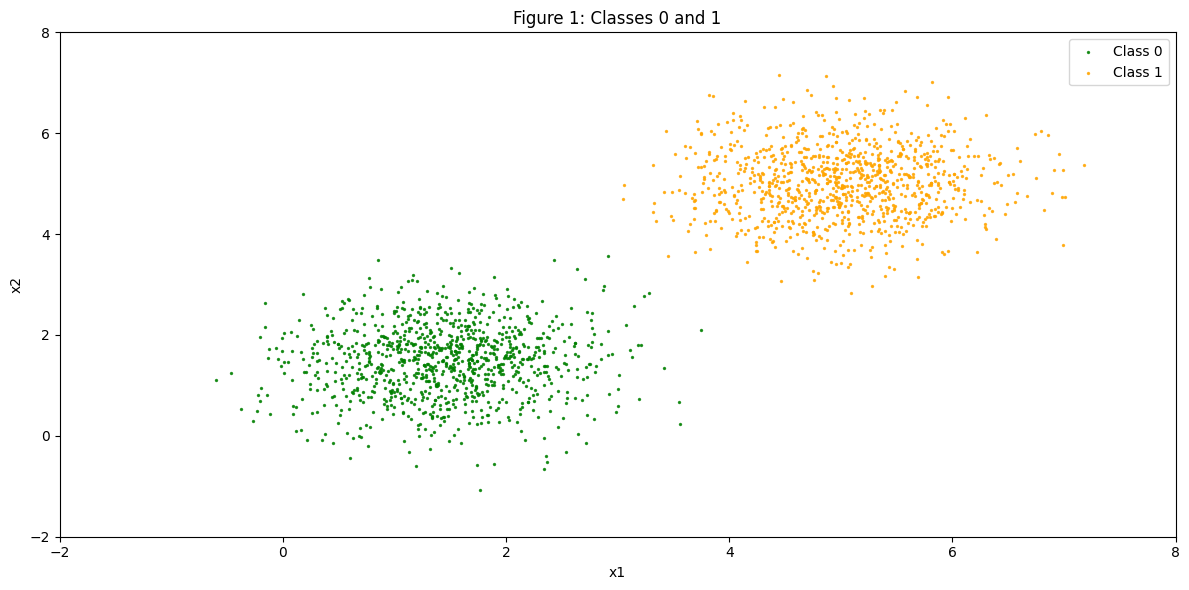

In [2]:
# Two classes drawn from multivariate normal distributions
n = 1000

class_0 = {
    'mean': [1.5, 1.5],
    'cov':[[0.5, 0],
           [0, 0.5]]
}

class_1 = {
    'mean': [5, 5],
    'cov':[[0.5, 0],
           [0, 0.5]]
}

class_0['data'] = rng.multivariate_normal(class_0['mean'], class_0['cov'], n)
class_1['data'] = rng.multivariate_normal(class_1['mean'], class_1['cov'], n)

plt.figure(figsize=(12, 6))
plt.scatter(class_0['data'][:, 0], class_0['data'][:, 1], s=2, c='green', alpha=0.8, label='Class 0')
plt.scatter(class_1['data'][:, 0], class_1['data'][:, 1], s=2, c='orange', alpha=0.8, label='Class 1')
plt.legend()
plt.xlim((-2, 8))
plt.ylim((-2, 8))
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Figure 1: Classes 0 and 1')
plt.tight_layout()
plt.show()


The classes seem linearly separable, just like required by the perceptron

### B - Implement the perceptron

Single layer perceptron in a compact class

In [3]:
class Perceptron():
    def __init__(self, size=2, lr=0.01, max_epochs=100):
        self.size = size
        self.lr = lr
        self.max_epochs = max_epochs

        self.w = rng.normal(0, 0.01, size=size)
        self.b = 0

        self.activation = lambda x: x >= 0  # noqa: E731
        
        self.e = 0


    def forward(self, x):
        z = x @ self.w + self.b
        y_hat = self.activation(z)
        return y_hat

    def backward(self, x, y, y_hat):
        error = y - y_hat
        self.w = self.w + self.lr * error * x
        self.b = self.b + self.lr * error
        self.epoch_diff = bool(error) or self.epoch_diff
        return error

    def _accuracy(self, X, Y):
        preds = self.forward(X)
        return (preds == Y).sum() / len(X)
        
    def train(self, X, Y, epochs=None, keep_best=False, log=True):
        assert len(X) == len(Y)
        if epochs: self.max_epochs = epochs
        
        ws = []
        bs = []
        accs = []

        if keep_best:
            self.best_w = None
            self.best_b = None
            self.best_acc = -np.inf
            self.best_acc_progression = []

        for e in range(self.max_epochs):
            self.e = e+1
            self.epoch_diff = 0

            for x, y in zip(X, Y):
                y_hat = self.forward(x)
                error = self.backward(x, y, y_hat)

                if keep_best and error: # There was an update
                    accuracy = self._accuracy(X, Y)
                    if accuracy > self.best_acc:
                        self.best_w = self.w.copy()
                        self.best_b = self.b
                        self.best_acc = accuracy
                        self.best_e = e + 1

            accuracy = self._accuracy(X, Y)
            ws.append(self.w), bs.append(self.b), accs.append(accuracy)

            if keep_best:
                self.best_acc_progression.append(self.best_acc)

            if log: print(f'Epoch {e + 1:3}: acc = {accuracy:.2%}')
            
            if not self.epoch_diff:
                print(f'Early stopping at epoch {e + 1}')
                break

        return ws, bs, accs



In [4]:
X = np.vstack((class_0['data'], class_1['data']))
Y = np.concat((np.zeros(n), np.ones(n)))


perceptron = Perceptron()
# Keeping the same initialization stable
initial_w = perceptron.w.copy()
initial_b = perceptron.b

ws, bs, accs = perceptron.train(X, Y)

Epoch   1: acc = 50.30%
Epoch   2: acc = 50.50%
Epoch   3: acc = 51.50%
Epoch   4: acc = 53.70%
Epoch   5: acc = 52.95%
Epoch   6: acc = 58.45%
Epoch   7: acc = 57.80%
Epoch   8: acc = 85.55%
Epoch   9: acc = 60.05%
Epoch  10: acc = 85.95%
Epoch  11: acc = 65.15%
Epoch  12: acc = 94.30%
Epoch  13: acc = 66.95%
Epoch  14: acc = 70.60%
Epoch  15: acc = 81.65%
Epoch  16: acc = 93.05%
Epoch  17: acc = 74.10%
Epoch  18: acc = 84.65%
Epoch  19: acc = 94.50%
Epoch  20: acc = 77.10%
Epoch  21: acc = 86.60%
Epoch  22: acc = 95.20%
Epoch  23: acc = 83.70%
Epoch  24: acc = 92.45%
Epoch  25: acc = 100.00%
Epoch  26: acc = 100.00%
Early stopping at epoch 26


In [5]:
ex1_w = perceptron.w.copy()
ex1_b = perceptron.b
ex1_epochs = perceptron.e
ex1_accuracy = accs[-1]

### C - Train and measure

The model was able to converge very quickly, given the linear separability of data.

In [6]:
print('Final w:', np.round(perceptron.w, 4))
print('Final b:', np.round(perceptron.b, 4))
print('Number of epochs:', perceptron.e)
print(f'Final accuracy: {accs[-1]:.2%}')


Final w: [0.0505 0.0289]
Final b: -0.25
Number of epochs: 26
Final accuracy: 100.00%


#### Decision boundary: 

$\mathbf{w} \cdot \mathbf{x} + b = 0$ 

$w_1x_1 + w_2x_2 + b = 0$

$w_2x_2 = - w_1x_1 - b$

$x_2 = - \frac{w_1x_1 + b}{w_2}$

In [7]:
from typing import Iterable
def plot_boundary(models, X, Y, fig=None, names=''):
    plt.figure(figsize=(12, 6))

    if not isinstance(models, Iterable):
        models = [models]
        names = [names]

    plt.scatter(X[Y == 0, 0], X[Y == 0, 1], label='Class 0', s=2, c='g')
    plt.scatter(X[Y == 1, 0], X[Y == 1, 1], label='Class 1', s=2, c='orange')

    for i, (model, name) in enumerate(zip(models, names)):
        y_pred = model.forward(X)
        misclassified = y_pred != Y
        
        # Misclassified
        red = rng.integers(50, 256) / 255
        plt.scatter(X[misclassified, 0], X[misclassified, 1], s=2,
                    facecolors='none', edgecolors=(red, 0, 0), linewidths=2, 
                    label=f'Misclassified  {name}')
        
        # Boundary
        x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        x1_vals = np.linspace(x1_min, x1_max, 200)

        w1, w2 = model.w
        b = model.b

        if w2 != 0:
            x2_vals = -(w1 * x1_vals + b) / w2
            plt.plot(x1_vals, x2_vals, label=f'Decision Boundary {name}')
        else:
            x_vertical = -b / w1
            plt.axvline(x_vertical, label=f'Decision Boundary {name}')
        
    
    plt.legend()
    plt.xlabel('x1'), plt.ylabel('x2')
    plt.title(f'Figure {fig}: Decision boundary w. misclassified points')
    plt.tight_layout()
    plt.show()



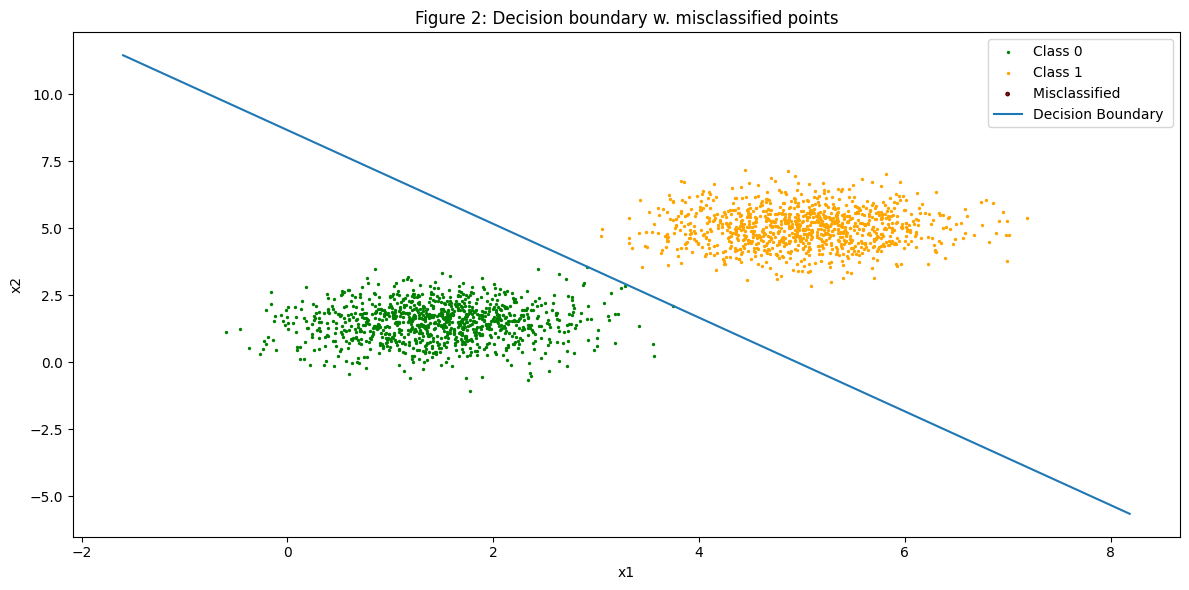

In [8]:
plot_boundary(perceptron, X, Y, 2)

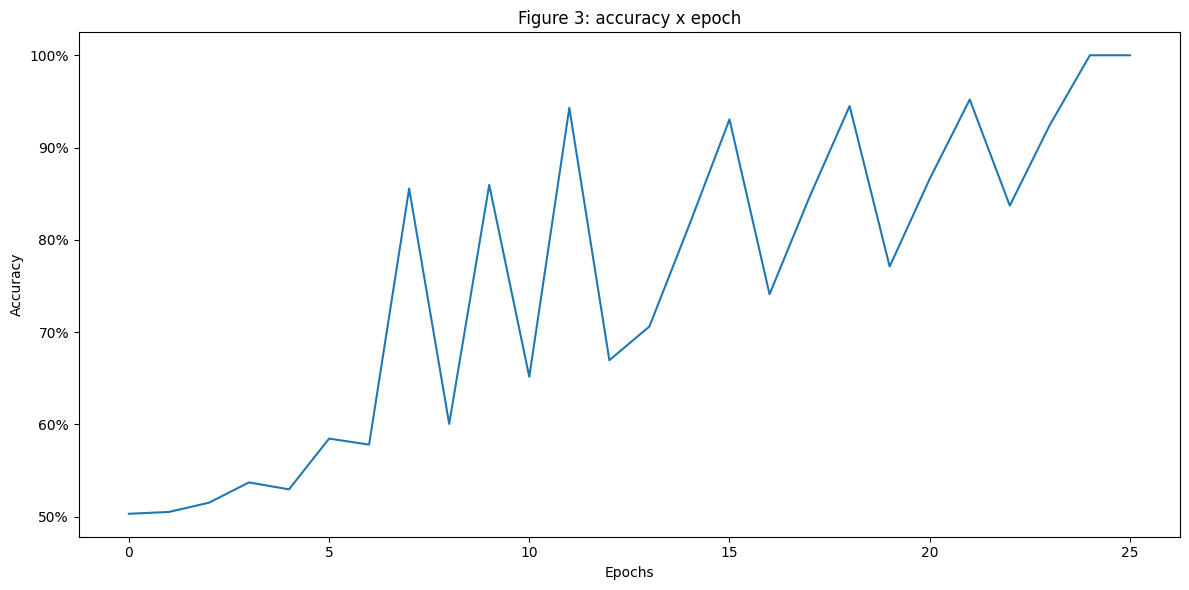

In [9]:
from matplotlib.ticker import PercentFormatter

plt.figure(figsize=(12, 6))
plt.title('Figure 3: accuracy x epoch')
plt.plot(np.arange(perceptron.e), accs)
plt.xlabel('Epochs'), plt.ylabel('Accuracy')
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.tight_layout()
plt.show()

### D - Analysis

1. The separable data do make the perceptron converge quite quickly, because the perceptron itself is essentially a linear classifier between classes. If the separation is linear, the perceptron can fit its line in between the two classes. The number of updates should get progressivelly smaller, as the model's precision rises, but the little remaining updates still lead the model to converge. Despite the fluctuations from the single sample updates, they converge with a quarter (26) of the reserved compute.

In [10]:
# Rerunning with lr=1

perceptron_lr1 = Perceptron(lr=1)
# Copying baseline weights to have the same initialization
perceptron_lr1.w = initial_w.copy()
perceptron_lr1.b = initial_b


ws_lr1, bs_lr1, accs_lr1 = perceptron_lr1.train(X, Y)

print('\n')
print('Final w:', np.round(perceptron_lr1.w, 4))
print('Final b:', np.round(perceptron_lr1.b, 4))
print('Number of epochs:', perceptron_lr1.e)
print(f'Final accuracy: {accs_lr1[-1]:.2%}')


Epoch   1: acc = 50.00%
Epoch   2: acc = 51.20%
Epoch   3: acc = 51.40%
Epoch   4: acc = 51.55%
Epoch   5: acc = 62.80%
Epoch   6: acc = 67.10%


Epoch   7: acc = 52.85%
Epoch   8: acc = 70.25%
Epoch   9: acc = 56.10%
Epoch  10: acc = 83.40%
Epoch  11: acc = 58.50%
Epoch  12: acc = 84.05%
Epoch  13: acc = 63.30%
Epoch  14: acc = 93.25%
Epoch  15: acc = 65.25%
Epoch  16: acc = 92.80%
Epoch  17: acc = 70.90%
Epoch  18: acc = 70.60%
Epoch  19: acc = 75.60%
Epoch  20: acc = 85.90%
Epoch  21: acc = 95.50%
Epoch  22: acc = 78.10%
Epoch  23: acc = 88.20%
Epoch  24: acc = 96.50%
Epoch  25: acc = 80.50%
Epoch  26: acc = 90.00%
Epoch  27: acc = 96.30%
Epoch  28: acc = 84.95%
Epoch  29: acc = 93.35%
Epoch  30: acc = 98.05%
Epoch  31: acc = 86.35%
Epoch  32: acc = 94.20%
Epoch  33: acc = 98.35%
Epoch  34: acc = 91.75%
Epoch  35: acc = 96.60%
Epoch  36: acc = 100.00%
Epoch  37: acc = 100.00%
Early stopping at epoch 37


Final w: [5.8706 3.3592]
Final b: -31.0
Number of epochs: 37
Final accuracy: 100.00%


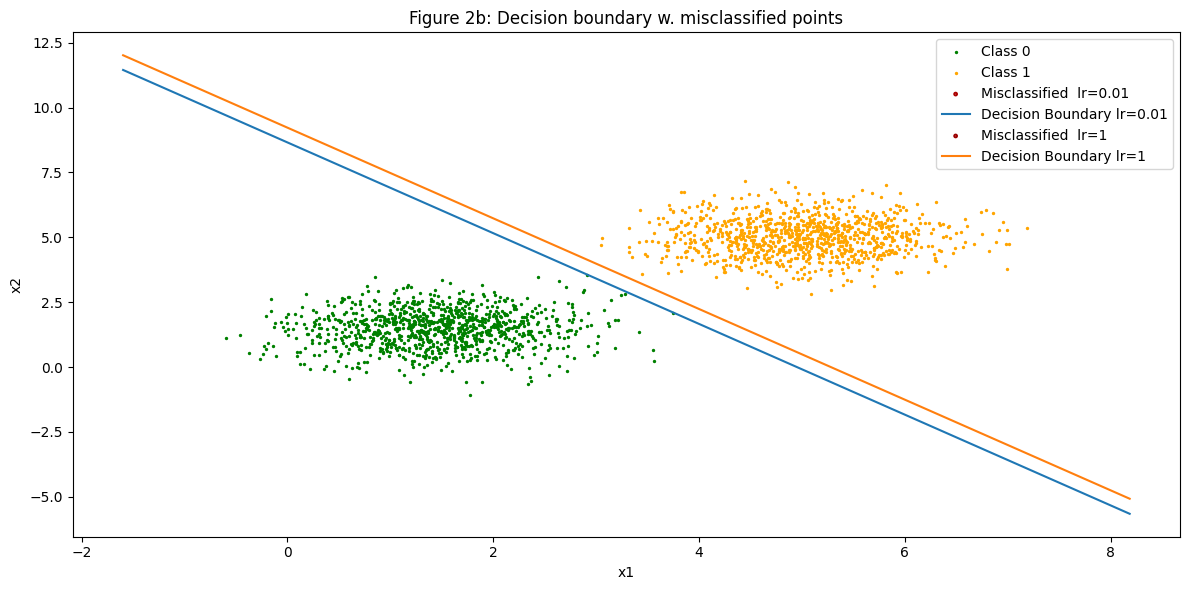

In [11]:
plot_boundary([perceptron, perceptron_lr1], X, Y, '2b', ['lr=0.01', 'lr=1'])

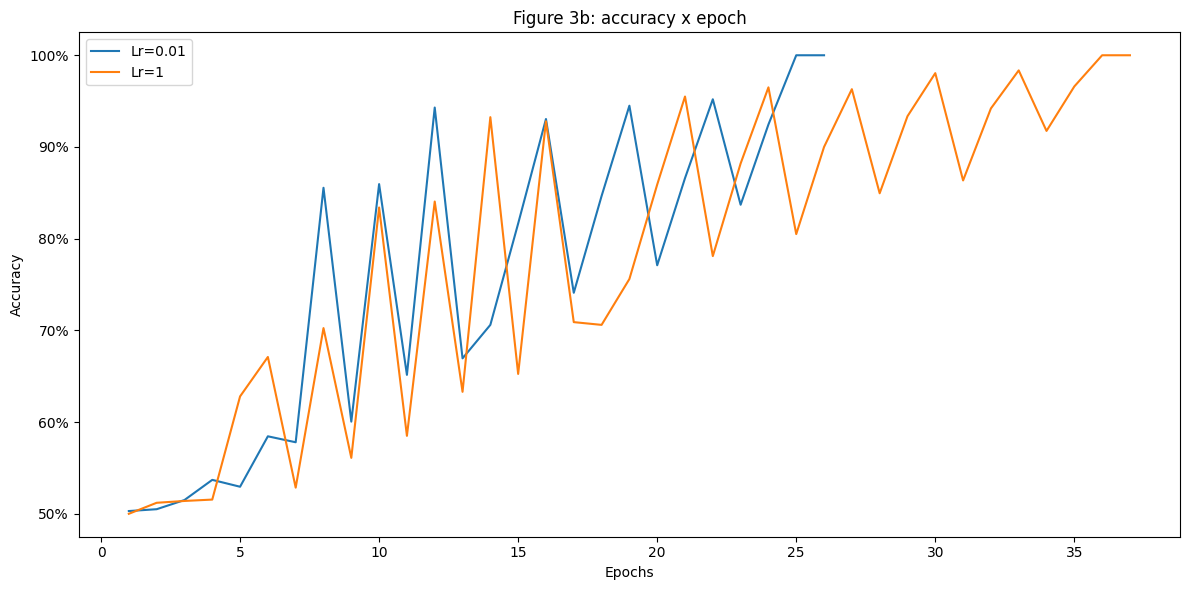

In [12]:
from matplotlib.ticker import PercentFormatter

plt.figure(figsize=(12, 6))
plt.title('Figure 3b: accuracy x epoch')
plt.plot(np.arange(1, perceptron.e+1), accs, label='Lr=0.01')
plt.plot(np.arange(1, perceptron_lr1.e+1), accs_lr1, label='Lr=1')
plt.xlabel('Epochs'), plt.ylabel('Accuracy')
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
direction_lr001 = perceptron.w / np.linalg.norm(perceptron.w)
direction_lr1 = perceptron_lr1.w / np.linalg.norm(perceptron_lr1.w)

print('Direction w. lr=0.01:', direction_lr001)
print('Direction w. lr=1:', direction_lr1)

Direction w. lr=0.01: [0.86812305 0.49634905]
Direction w. lr=1: [0.86794992 0.49665172]


2. 
The new model was also able to reach 100% accuracy with a little more time, in 32 epochs. Looking at figure 3b, we can see that the higher learning rate makes the model unstable for longer, even if it ultimately converges. 

The directions are a bit different, with [0.86812305 0.49634905] for the lr=0.01 and [0.79956325 0.60058189] for lr=1. This happened because the weights were initialized randomly, so they were updated differently throughout the training run. They reached the same accuracy level, but in different ways. 

Eta is the learning rate: the magnitude of the change to be applied in the model's parameters based on observed errors. It is used to smoothen learning, to make sure that the model does not extrapolates the observed error from one sample as if that is the error the model would get for the whole population. Given that we are only using a single data point for each update, a small learning rate is appropriate to make sure that the model does not keep on overshooting its parameters.

3. 
If both weights are initialized equally, updates to them are also applied equally.  

Because both start from $\mathbf{w}=0, b=0$, both will start by making the same prediction, thus having the same errors.

In the first update, both the $\eta_1$ and the $\eta_2$ models will be updated in the same direction, just with different learning rates:

$$
\begin{aligned}
\mathbf{w}'_1 &= \mathbf{w}_1 + \eta_1(y-\hat{y}) \cdot x\\
\mathbf{w}'_2 &= \mathbf{w}_2 + \eta_2(y-\hat{y}) \cdot x\\
\end{aligned}
$$

Because both started at 0, $\mathbf{w}'_2 = \frac{\eta_2}{\eta_1}\mathbf{w}'_1$ and $b'_2 = \frac{\eta_2}{\eta_1}b'_1$. 

For the next sample, the prediction of the second model, $\mathbf{w}'_2\cdot x+b'_2$ will be proportional by $\frac{\eta_2}{\eta_1}$ to the prediction of the first, $\mathbf{w}'_1\cdot x+b'_1$. Then, because predictions are binary 1/0, and $\frac{\eta_2}{\eta_1} > 0$, the score sign is preserved, leading both to have the same error $ e = y - \hat{y} $. This will lead to another proportional update, and so on for all the samples. As such, both runs will have identical predictions, with differences only in the magnitudes of their weights and bias.

This difference is insignificant for the decision boundary itself, $x_2 = - \frac{w_1x_1 + b}{w_2}$, as $\frac{w_1}{w_2}$ is constant and equal to 1 because w1 and w2 are updated equally. 


## Exercise 2 - Overlapping Data: the case the perceptron cannot solve

### A - Generate the data

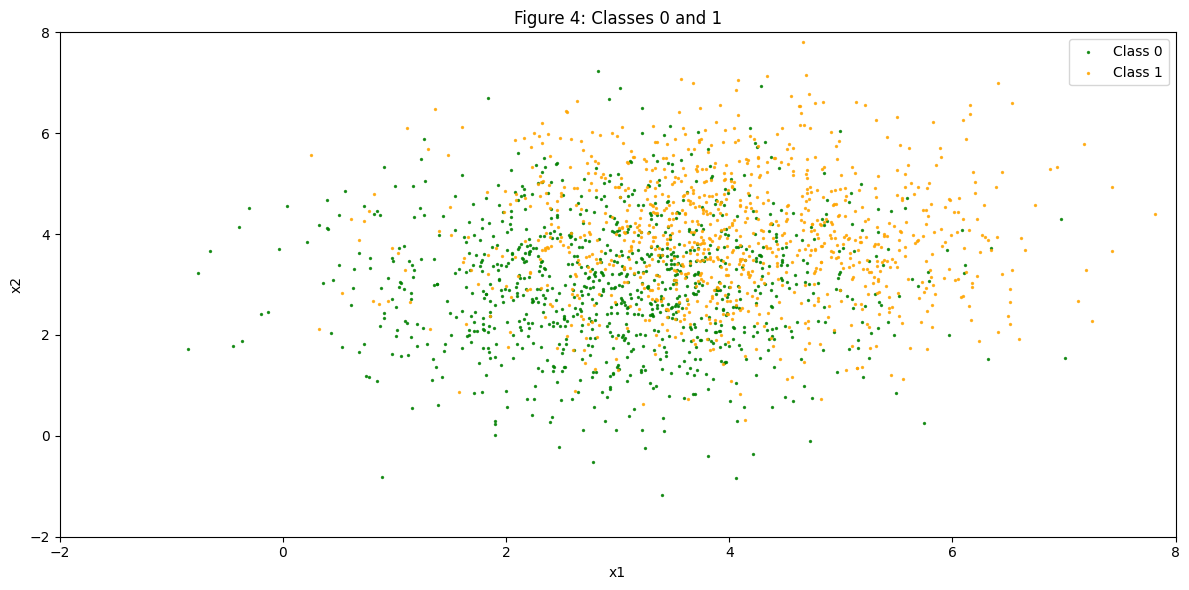

In [14]:
# Two new classes, now overlapped
n = 1000

class_0 = {
    'mean': [3, 3],
    'cov':[[1.5, 0],
           [0, 1.5]]
}

class_1 = {
    'mean': [4, 4],
    'cov':[[1.5, 0],
           [0, 1.5]]
}

class_0['data'] = rng.multivariate_normal(class_0['mean'], class_0['cov'], n)
class_1['data'] = rng.multivariate_normal(class_1['mean'], class_1['cov'], n)

plt.figure(figsize=(12, 6))
plt.scatter(class_0['data'][:, 0], class_0['data'][:, 1], s=2, c='green', alpha=0.8, label='Class 0')
plt.scatter(class_1['data'][:, 0], class_1['data'][:, 1], s=2, c='orange', alpha=0.8, label='Class 1')
plt.legend()
plt.xlim((-2, 8))
plt.ylim((-2, 8))
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Figure 4: Classes 0 and 1')
plt.tight_layout()
plt.show()


#### B - Train, keeping the best weights

Pocket weights for preserving the best weights

In [15]:
X = np.vstack((class_0['data'], class_1['data']))
Y = np.concat((np.zeros(n), np.ones(n)))

perceptron = Perceptron()
ws, bs, accs = perceptron.train(X, Y, keep_best=True, log=False)

print('Final weights:')
print('Final w:', np.round(perceptron.w, 4))
print('Final b:', np.round(perceptron.b, 4))
print('Total epochs:', perceptron.e)
print(f'Final accuracy: {accs[-1]:.2%}')
print('\nPocket weights:')
print('Best w:', np.round(perceptron.best_w, 4))
print('Best b:', np.round(perceptron.best_b, 4))
print('Best epoch:', perceptron.best_e)
print(f'Best accuracy: {perceptron.best_acc:.2%}')

Final weights:
Final w: [0.0659 0.0464]
Final b: -0.12
Total epochs: 100
Final accuracy: 50.65%

Pocket weights:
Best w: [0.0131 0.018 ]
Best b: -0.11
Best epoch: 74
Best accuracy: 71.40%


### C - Figures

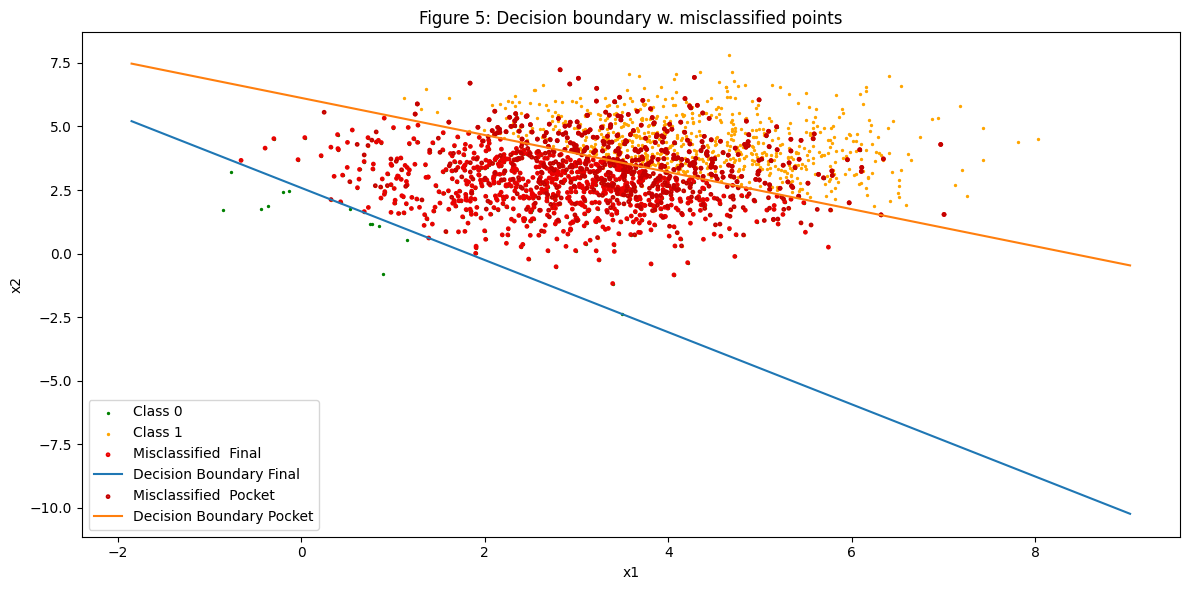

In [16]:
best_perceptron = Perceptron()
best_perceptron.w = perceptron.best_w
best_perceptron.b = perceptron.best_b

plot_boundary((perceptron, best_perceptron), X, Y, '5', ('Final', 'Pocket'))

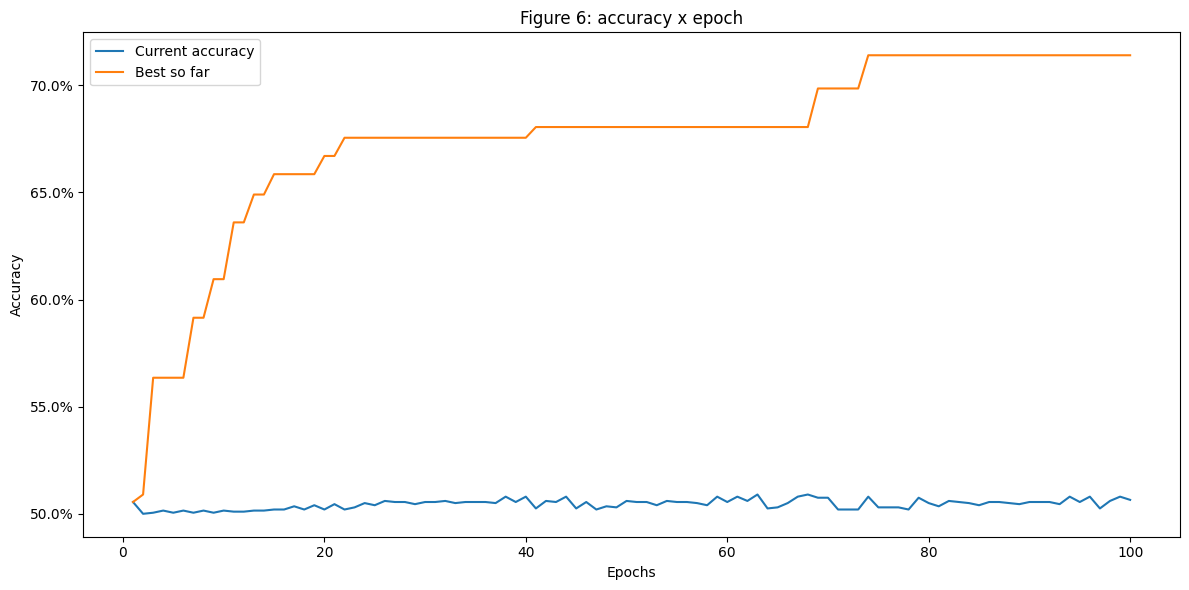

In [17]:

plt.figure(figsize=(12, 6))
plt.title('Figure 6: accuracy x epoch')
plt.plot(np.arange(1, perceptron.e + 1), accs, label='Current accuracy')
plt.plot(np.arange(1, perceptron.e + 1), perceptron.best_acc_progression, label='Best so far')
plt.xlabel('Epochs'), plt.ylabel('Accuracy')
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.legend()
plt.tight_layout()
plt.show()

### D - Analysis

1. Because the data are not linearly separable and the perceptron updates one sample at a time, mistakes continue and the boundary keeps moving. Each update corrects an individual mistake but can reduce overall accuracy, so training can move away from a good boundary. The pocket weights method preserves the best boundary encountered, even if by chance, because somewhere among the dataset there exists a linear boundary that will get a slightly better accuracy. The final boundary ends up sitting almost outside the data cloud, assigning the vast majority of points to one class and achieving 50% accuracy on this balanced dataset.

2. It guarantees that the perceptron will converge if the classes are linearly separable. Exercise 1 staisties this condition, so training eventually stops updating and accuracy settles. Exercise 2 does not have linearly separable data, so mistakes and updates persist. The pocket accuracy can still plateau because it retains the best result seen, which might be the best result possible for a linear separation of a non-linear dataset.

3. Neither removes the lack of separability. As training is executed from a single sample, any mistake causes an update. More epochs allow further updates but they will never create a separating line. A smaller $\eta$ reduces the magnitude of each update, but mistakes still occur, so it cannot converge either. 

## Results summary

In [18]:
from IPython.display import display

summary = pd.DataFrame({
    "#": range(1, 9),
    "Quantity": [
        "Exercise 1 — final w and b",
        "Exercise 1 — epochs to convergence",
        "Exercise 1 — final accuracy",
        "Exercise 1 — epochs and final accuracy with η = 1.0",
        "Exercise 2 — final w and b",
        "Exercise 2 — accuracy of the final weights",
        "Exercise 2 — accuracy of the pocket weights",
        "Exercise 2 — epoch at which the pocket best occurred",
    ],
    "Value": [
        f"w = {np.round(ex1_w, 4).tolist()}, b = {ex1_b:.4f}",
        str(ex1_epochs),
        f"{ex1_accuracy:.2%}",
        f"{perceptron_lr1.e} epochs; {accs_lr1[-1]:.2%}",
        f"w = {np.round(perceptron.w, 4).tolist()}, b = {perceptron.b:.4f}",
        f"{accs[-1]:.2%}",
        f"{perceptron.best_acc:.2%}",
        str(perceptron.best_e),
    ],
})

display(summary.style.hide(axis="index"))

#,Quantity,Value
1,Exercise 1 — final w and b,"w = [0.0505, 0.0289], b = -0.2500"
2,Exercise 1 — epochs to convergence,26
3,Exercise 1 — final accuracy,100.00%
4,Exercise 1 — epochs and final accuracy with η = 1.0,37 epochs; 100.00%
5,Exercise 2 — final w and b,"w = [0.0659, 0.0464], b = -0.1200"
6,Exercise 2 — accuracy of the final weights,50.65%
7,Exercise 2 — accuracy of the pocket weights,71.40%
8,Exercise 2 — epoch at which the pocket best occurred,74
